# Dataset 9 — Meningitis Dataset with Missing Values (Kaggle)

## Descripción general
Este dataset clínico de Kaggle contiene perfiles de pacientes evaluados por sospecha de Meningitis. Incluye marcadores bioquímicos críticos como niveles de glucosa y proteína en el líquido cefalorraquídeo, conteo de glóbulos blancos (WBC) y niveles de PCR. Su característica principal, como indica su nombre, es la inyección deliberada de **valores faltantes (Missing Values)** para simular el ruido e incompletitud típicos del mundo médico real.

## Objetivo
**Problema de Clasificación Binaria** — Predecir el desenlace final del paciente (`Outcome`), clasificándolo como **Recuperado** (`0`) o **Fallecido** (`1`), basándose en sus métricas hematológicas y clínicas.

## Tratamiento aplicado y Justificaciones Técnicas

### 1. Eliminación de Data Leakage
La primera columna evaluada fue `Patient_ID`. 
- **Acción:** Se eliminó del conjunto de datos.
- **Justificación:** Los números de expediente médico son ruido estadístico. Conservarlos permitiría al modelo memorizar al paciente en lugar de aprender los biomarcadores que provocan la enfermedad, anulando su capacidad predictiva.

### 2. Imputación Rigurosa de Valores Faltantes (El Reto Principal)
Al ser un dataset diseñado con valores faltantes, este fue el paso más crítico.
- **Variables Numéricas (Ej. Edad, WBC, Glucosa):** Se imputaron utilizando la **mediana** poblacional. En clínica, los marcadores como la Proteína C Reactiva (CRP) pueden tener valores atípicos extremos por infecciones severas; la mediana es robusta frente a estos *outliers*, evitando que la imputación se distorsione.
- **Variables Categóricas (Ej. Género, Diagnóstico):** Se imputaron con la **moda** (el valor más frecuente), preservando la distribución demográfica del hospital.

### 3. Mapeo Binario de la Variable Objetivo
Para la Regresión Logística, la columna `Outcome` fue mapeada:
- **`Recovered` (Recuperado)** $\rightarrow$ **0**
- **`Deceased` (Fallecido)** $\rightarrow$ **1**

### 4. Codificación de Categorías Complejas
Se aplicó **One-Hot Encoding** (`pd.get_dummies`) a columnas como `Risk_Level` y `Pathogen_Present`, transformándolas en características binarias independientes que el Descenso de Gradiente puede procesar matemáticamente sin asumir falsas jerarquías.

### 5. Balanceo de Clases (Undersampling)
En enfermedades críticas, la tasa de supervivencia suele ser mayor que la de mortalidad, creando un desbalance clínico.
- **Acción:** Se aplicó **Undersampling aleatorio** a la clase de recuperados hasta igualar matemáticamente el número de pacientes fallecidos.
- **Justificación:** Un modelo médico debe ser capaz de predecir la muerte con la misma sensibilidad que la supervivencia. Sin balanceo, el algoritmo tendería a predecir "Recuperado" sistemáticamente para inflar su *Accuracy*.

### 6. Preparación para Entrenamiento Matemático
- **División 80/20:** Para separar el aprendizaje de la evaluación y prevenir el *Overfitting*.
- **Normalización (Z-score):** Vital en este dataset, ya que marcadores como `Platelets` están en cientos de miles, mientras que `Hemoglobin` está en el rango de decenas. Sin estandarización, las plaquetas dominarían engañosamente el gradiente matemático.
- **Término de Bias ($\theta_0$):** Inserción de un vector de unos en la matriz final $X$.

## Resultado final
| Métrica | Tratamiento |
|--|---------|
| **Problema** | Clasificación Binaria (Pronóstico de Mortalidad) |
| **Nulos Restantes** | 0 (Imputación estricta completada) |
| **Ingeniería** | Eliminación de Identificadores + One-Hot Encoding |
| **Balance de clases** | 50% / 50% (Mediante Undersampling) |

## ¿Está balanceado?
**Sí.** Gracias a la técnica de submuestreo, el dataset final posee el mismo número de perfiles clínicos para pacientes que sobrevivieron y aquellos que fallecieron. Esto garantiza una frontera de decisión justa y matemática en la clasificación predictiva.

Shape original: (1200, 14)

Variable objetivo - Outcome (Distribución original):
Outcome
Recovered    1069
Deceased      121
NaN            10
Name: count, dtype: int64

Shape tras eliminar 'Patient_ID': (1200, 13)

Ninguna columna superó el 50% de nulos.
NaN totales restantes tras imputación rigurosa: 0
Shape después de One-Hot Encoding: (1200, 19)

Balanceando las clases (Undersampling)...
Distribución después del balanceo:
Outcome
0    121
1    121
Name: count, dtype: int64

 DESCRIPCIÓN DEL DATASET PREPARADO 
Nombre: Meningitis Dataset with Missing Values
Problema: Clasificación Binaria (Pronóstico Clínico)
Filas listas: 242
Columnas predictoras: 18

Dataset guardado como 'Meningitis_preparado.csv'

 INICIANDO DIVISIÓN 80/20 Y NORMALIZACIÓN 
Tamaño X_train_norm: (193, 19)
Tamaño X_test_norm:  (49, 19)


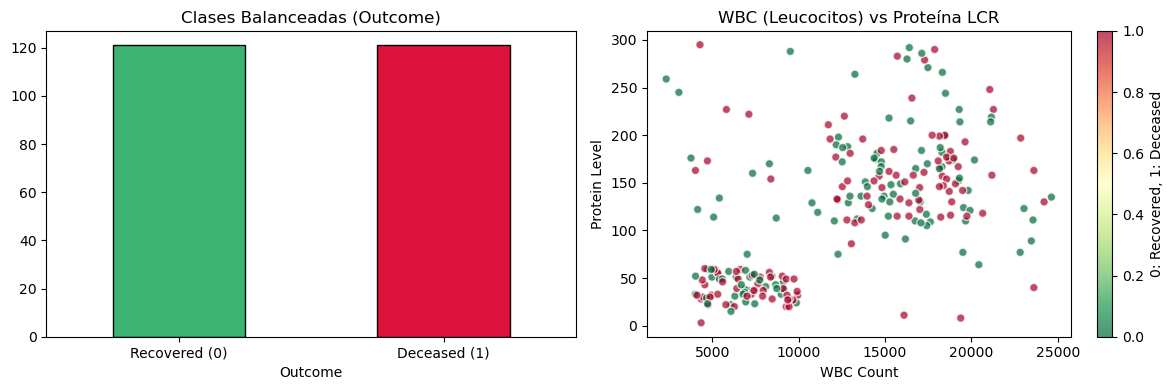

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# PREPARACIÓN DATASET 9: Meningitis (Clasificación)

# 1. CARGAR
ruta_meningitis = r"C:\Users\Usuario\Documents\7mo semestre\Sis420\PrimerParcial\Dataset9\mening missing 12.csv"

# Cargamos el dataset
df = pd.read_csv(ruta_meningitis)

print("Shape original:", df.shape)
print("\nVariable objetivo - Outcome (Distribución original):")
print(df['Outcome'].value_counts(dropna=False))

# 2. ELIMINAR COLUMNAS INÚTILES
# Patient_ID es solo un número de registro, causa sobreajuste (Data Leakage)
if 'Patient_ID' in df.columns:
    df = df.drop(columns=['Patient_ID'])
    print("\nShape tras eliminar 'Patient_ID':", df.shape)

# 3. ELIMINAR COLUMNAS CON >50% DE NaN
umbral = 0.5 * len(df)
cols_muchos_nulos = df.columns[df.isnull().sum() > umbral].tolist()
if cols_muchos_nulos:
    df = df.drop(columns=cols_muchos_nulos)
    print(f"\nColumnas eliminadas por >50% NaN: {cols_muchos_nulos}")
else:
    print("\nNinguna columna superó el 50% de nulos.")

# 4. IMPUTAR NaN RESTANTES (EL PASO ESTRELLA DE ESTE DATASET)
# Este dataset está diseñado para tener nulos. Los imputamos rigurosamente.
cols_numericas = df.select_dtypes(include=['int64', 'float64']).columns
for col in cols_numericas:
    if df[col].isnull().sum() > 0:
        mediana = df[col].median()
        df[col] = df[col].fillna(mediana)

cols_texto = df.select_dtypes(include='object').columns
for col in cols_texto:
    if df[col].isnull().sum() > 0:
        moda = df[col].mode()[0]
        df[col] = df[col].fillna(moda)

print("NaN totales restantes tras imputación rigurosa:", df.isnull().sum().sum())

# 5. CODIFICACIÓN DE LA META Y ONE-HOT ENCODING
# Mapeamos la meta: Recovered -> 0 (Sano), Deceased -> 1 (Fallecido)
# Limpiamos espacios en blanco por si acaso
df['Outcome'] = df['Outcome'].str.strip()
df['Outcome'] = df['Outcome'].map({'Recovered': 0, 'Deceased': 1})

# Si quedó algún Outcome rarísimo o nulo (que no sea Recovered/Deceased), lo borramos
df = df.dropna(subset=['Outcome'])

# One-Hot Encoding para el resto de variables de texto (Gender, Diagnosis, Risk_Level, etc.)
cols_cat = df.select_dtypes(include='object').columns.tolist()
df = pd.get_dummies(df, columns=cols_cat)
print("Shape después de One-Hot Encoding:", df.shape)

# 6. BALANCEAR CLASES (Undersampling)
print("\nBalanceando las clases (Undersampling)...")
clase_mayoritaria = df[df['Outcome'] == 0] # Sobrevivientes
clase_minoritaria = df[df['Outcome'] == 1] # Fallecidos

# Igualamos para evitar que el modelo siempre prediga "Recovered"
clase_mayoritaria_reducida = clase_mayoritaria.sample(n=len(clase_minoritaria), random_state=42)
df = pd.concat([clase_mayoritaria_reducida, clase_minoritaria])

# Mezclamos aleatoriamente
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print("Distribución después del balanceo:")
print(df['Outcome'].value_counts())

# 7. MOVER TARGET AL FINAL
cols = [c for c in df.columns if c != 'Outcome'] + ['Outcome']
df = df[cols]

# 8. RESUMEN FINAL
print("\n DESCRIPCIÓN DEL DATASET PREPARADO ")
print(f"Nombre: Meningitis Dataset with Missing Values")
print(f"Problema: Clasificación Binaria (Pronóstico Clínico)")
print(f"Filas listas: {df.shape[0]}")
print(f"Columnas predictoras: {df.shape[1] - 1}")

# 9. GUARDAR
df.to_csv('Meningitis_preparado.csv', index=False)
print("\nDataset guardado como 'Meningitis_preparado.csv'")

# 10. DIVISIÓN 80/20 Y NORMALIZACIÓN MATEMÁTICA
print("\n INICIANDO DIVISIÓN 80/20 Y NORMALIZACIÓN ")

# .astype(float) evita errores con tipos booleanos post One-Hot
X = df.drop('Outcome', axis=1).astype(float).values
y = df['Outcome'].values

m = len(y)
limite = int(m * 0.8)

# División 80/20
X_train, X_test = X[:limite], X[limite:]
y_train, y_test = y[:limite], y[limite:]

# Función Z-Score Manual
def normalizar(X_data):
    mu = np.mean(X_data, axis=0)
    sigma = np.std(X_data, axis=0)
    sigma[sigma == 0] = 1 
    return (X_data - mu) / sigma, mu, sigma

# Normalizar
X_train_norm, mu, sigma = normalizar(X_train)
X_test_norm = (X_test - mu) / sigma

# Columna de unos (sesgo/intercepto theta_0)
X_train_norm = np.concatenate([np.ones((X_train_norm.shape[0], 1)), X_train_norm], axis=1)
X_test_norm = np.concatenate([np.ones((X_test_norm.shape[0], 1)), X_test_norm], axis=1)

print(f"Tamaño X_train_norm: {X_train_norm.shape}")
print(f"Tamaño X_test_norm:  {X_test_norm.shape}")

# 11. GRÁFICAS
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
df['Outcome'].value_counts().plot(kind='bar', color=['mediumseagreen', 'crimson'], edgecolor='black')
plt.title("Clases Balanceadas (Outcome)")
plt.xticks([0, 1], ['Recovered (0)', 'Deceased (1)'], rotation=0)

plt.subplot(1, 2, 2)
# Gráfica de Leucocitos vs Proteína por Resultado
scatter = plt.scatter(df['WBC_Count'], df['Protein_Level'], c=df['Outcome'], cmap='RdYlGn_r', alpha=0.7, edgecolors='w')
plt.title("WBC (Leucocitos) vs Proteína LCR")
plt.xlabel("WBC Count")
plt.ylabel("Protein Level")
plt.colorbar(scatter, label='0: Recovered, 1: Deceased')

plt.tight_layout()
plt.show()